<a href="https://colab.research.google.com/github/mjss26/EMSC2010-Group-Project-5/blob/main/EMSC2010_Group_Project_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010 Group Project 5

## 1. Project Overview
Group name: Bugs, Bush & Biodiversity

Project week: Friday week 10 - Friday week 11

Project title: Analysis of ENSO Trends 1954-2025

Datasets used: Extended Reconstructed Sea Surface Temperature (ERSST) Version 5, National Oceanic and Atmospheric Administration (NOAA). [LINK](https://www.ncei.noaa.gov/access/metadata/landing-page/bin/iso?id=gov.noaa.ncdc:C00927).

## 2. Roles and contributions

| Role | Primary | Deputy | Completed? | Notes |
| :--- | :--- | :--- | :--- | :--- |
| GitHub & Integration | MJ | Mia | Yes | Add note |
| Data Steward | Mia | Sonya | Yes | Add note |
| Analysis / Modelling | Sonya | Sienna | Yes | Add note |
| Visualisation / Interpretation | Sienna | Seth | Yes | Add note |
| Narrative | Seth | MJ | Yes | Add note |
| Quality Control / Reproducibility | N/A | N/A | Yes | Add note |

## 3. Deputy Interventions

* **Role affected:** Analysis

* **Reason (e.g. missed deadline, absence, etc.):**
Communication was missed after initial analysis was complete

* **Deputy action taken:**
Sienna, Seth, MJ, and Mia all worked as a team to resolve issues and complete the rest of the project

* **Impact on workflow:**
After Seth and Mia received advice in one of the tutorials about the analysis, they reached out to Sonya and the group via Canvas. It appears the message was not received, so the deputy Sienna initially intervened to complete the analysis which largely needed to be redone. After running out of time to complete the remaining analysis, and much of the Visualisation role, Sienna reached out to the group via Canvas Announcement. As seen on the Canvas page the other group members all stepped in to take on a variety of the different assigned roles and finish the project. We were able to communicate more easily on messaging platforms to arrange details and exchange thoughts and ideas.

This impacted the workflow as the re-working of the analysis began on Thursday, meaning all remaining roles also had to be completed on Thursday in order to meet the Friday submission deadline.

*N.B., this section should be factual, not judgmental.

## 4. Pre-submission checklist
* Notebook runs from top to bottom.
* Data files are included in the GitHub repository.
* Commits include meaningful information.
* Each group member has included a brief reflection in the notebook.
* Repository has been shared with the teaching team once your project is completed.

The project was inspired by an interest in Australia's large-scale climatic variability systems and how they affect different parts of our environment. This led to an analysis of the El Niño Southern Oscillation (ENSO) for the El Niño 3.4 region, in which variation between states of La Niña, Neutral, and El Niño affects not only the east coast of Australia, but the continent as a whole.

**Data Methods**

Source: https://www.ncei.noaa.gov/access/metadata/landing-page/bin/iso?id=gov.noaa.ncdc:C00927

Citation: Boyin Huang, Peter W. Thorne, Viva F. Banzon, Tim Boyer, Gennady Chepurin, Jay H. Lawrimore, Matthew J. Menne, Thomas M. Smith, Russell S. Vose, and Huai-Min Zhang (2017): NOAA Extended Reconstructed Sea Surface Temperature (ERSST), Version 5. [elnino.sst.data]. NOAA National Centers for Environmental Information. doi:10.7289/V5T72FNM [Accessed 15/5/2026].

To investigate the research question, a database from the National Oceanic and Atmospheric Administration (NOAA) containing El Niño and Sea Surface Temperature (SST) data was identified. The online dataset (available here: [LINK](https://www.ncei.noaa.gov/pub/data/cmb/ersst/v5/index/ersst.v5.el_nino.sst.dat)) was converted into an Excel sheet using ChatGPT, with metadata and FAIR data principles included. The dataset includes monthly SST measurements for different El Niño regions from 1854 to April 2026 and is updated on a continuous basis. The dataset was narrowed for analysis to include only SST data points from January 1854 to December 2025, with focus on the El Niño 3.4 region. The El Niño 3.4 region was selected because this region has the greatest impact on Australia's climate, and is used by the Bureau of Meteorology (BoM) for ENSO forecasting (sources: [BoM](https://www.bom.gov.au/climate/enso/?ninoIndex=nino3.4&index=rnino34&period=weekly), [NOAA](https://www.ncei.noaa.gov/access/monitoring/enso/sst)). Therefore, this project conducts a time-series analysis that can be representative of Australia's ENSO climate trends and cycles.  

---

**Additional Sources:**

https://www.bom.gov.au/climate/change/about/sst_timeseries.shtml

https://journals.ametsoc.org/view/journals/clim/30/20/jcli-d-16-0836.1.xml

The aim of the analysis is to apply a moving average to the SST data (1854-2025) in order to smooth out the noise, making it possible to identify ENSO cycles, which are defined largely by anomalies in SST.

In [ ]:
import numpy as np # NumPy for numerical computing
import matplotlib.pyplot as plt #plotting library
import pandas as pd #Pandas for data handling

In [ ]:
#reading in data file and creating dataframe
file = 'ERSST_El_Nino_SST_Data.xlsx' #read in data excel file
df = pd.read_excel(file, sheet_name='Sheet1') #read file and 'Sheet1' into df
df.head() #show the header information

,Year,Month,Nino1.2_SST (℃),Nino3_SST (℃),Nino3.4_SST (℃),Nino4_SST (℃),Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,1854,1,25.46,27.69,25.90,23.97,NaN,NaN,NaN,NaN
1,1854,2,26.12,27.77,26.06,25.54,NaN,NaN,NaN,NaN
2,1854,3,26.79,28.10,26.91,25.28,NaN,NaN,NaN,NaN
3,1854,4,27.19,28.42,27.63,23.95,NaN,NaN,NaN,NaN
4,1854,5,26.99,28.86,27.90,22.80,NaN,NaN,All El Nino Sea Surface Temperature (SST) valu...,NaN


In [43]:
# Creating dataframe with values we are interested in: year, month, El Niño sea surface temperature (°C) for region 3.4

df_sst = df[['Year', 'Month', 'Nino3.4_SST (℃)']].copy()
df_sst = df_sst.dropna() #remove rows with NaN missing values
Year = df_sst['Year'].to_numpy() #convert years into numpy array
month = df_sst['Month'].to_numpy() #convert months into numpy array
year = Year + month/12 #time as year.month
sst = df_sst['Nino3.4_SST (℃)'].to_numpy() #convert sst into numpy array
df_sst.head() # Show the header information

,Year,Month,Nino3.4_SST (℃)
0,1854,1,25.90
1,1854,2,26.06
2,1854,3,26.91
3,1854,4,27.63
4,1854,5,27.90


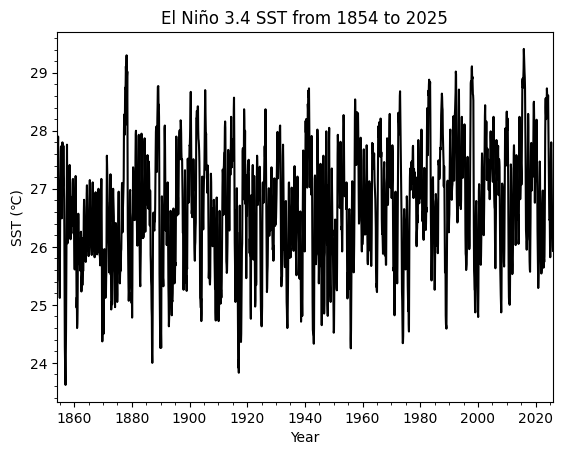

In [44]:
# plot to check data frame

plt.plot(year,sst,'black') #Plot year and sst data
plt.xlabel('Year')
plt.ylabel('SST (℃)')
plt.title('El Niño 3.4 SST from 1854 to 2025')
plt.minorticks_on()
plt.xlim(1854, max(year)) #Set x-axis limit to start from 1854
plt.show()

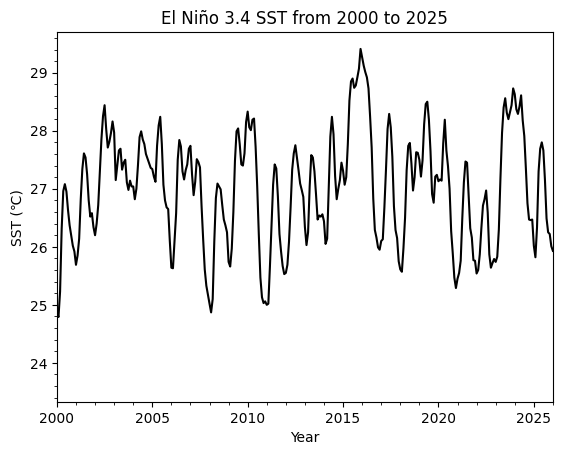

In [45]:
#do we need this?
#zoom in

plt.plot(year,sst,'black') #Plot year and sst data
plt.xlabel('Year')
plt.ylabel('SST (℃)')
plt.title('El Niño 3.4 SST from 2000 to 2025')
plt.minorticks_on()
plt.xlim(2000, max(year)) #Set x-axis limit to start from 1854
plt.show()

In [ ]:
#Code cell and contents added by Seth:
order = 40 #set the polynomial order
pp = np.polyfit(year,sst,order) #fit the polynomial, pp will contain the polynomial coefficients
trend = np.polyval(pp,year) #find the value of the polynomial at each time point.

/tmp/ipykernel_5076/2829403051.py:3: RankWarning: Polyfit may be poorly conditioned
  pp = np.polyfit(year,sst,order) #fit the polynomial, pp will contain the polynomial coefficients


/tmp/ipykernel_5076/2254561797.py:15: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r" (-> color=(1.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(year,trend,'r',label='Trend', color='red') #plot the trend


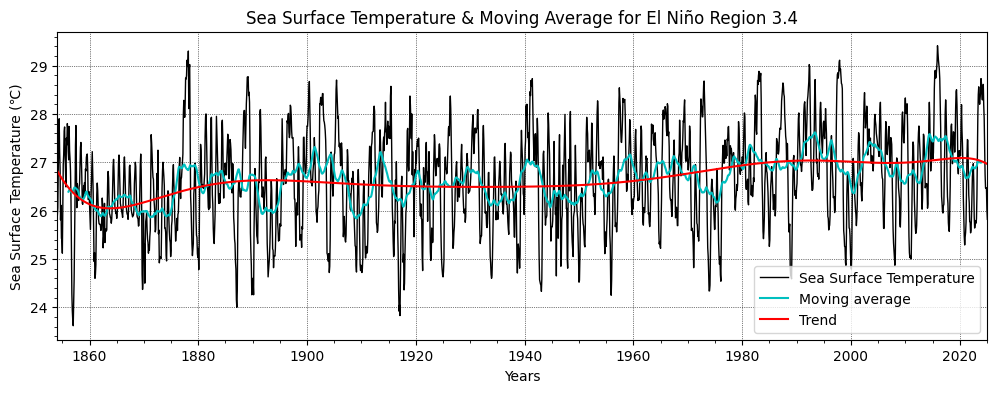

In [46]:
#GRAPH 1: Sea Surface Temp (sst) raw data and moving average based on sst plotted together to visualise correlation

#using data from dataframs; 'year' and 'sst'

def moving_average(sst,w):
  return np.convolve(sst, np.ones(w), 'valid' ) / w #moving average function

w = 50 #length of the moving average
p_sst = moving_average(sst, w) #process the sst
p_year = moving_average(year, w) #process the time

plt.figure(figsize=(12, 4)) #figure used to 'stretch out' x-axis and make data less cramped
plt.plot(year,sst,'k',linewidth=1,label='Sea Surface Temperature') #plot the raw data
plt.plot(p_year,p_sst,'c',label='Moving average') #plot the moving average
plt.plot(year,trend,'r',label='Trend', color='red') #plot the trend
plt.xlim([1854,2025]) #limit the x-axis
plt.title('Sea Surface Temperature & Moving Average for El Niño Region 3.4')
plt.xlabel('Years') #label the x-axis
plt.ylabel('Sea Surface Temperature (℃)') #label the y-axis
plt.legend() #add a legend
plt.minorticks_on() #add minorticks
plt.grid(which='major', linestyle=':', linewidth='0.5', color='black')

In [ ]:
#Code cell and contents added by Seth:
p_order = 40 #set the polynomial order
p_pp = np.polyfit(p_year,p_sst,p_order) #fit the polynomial, pp will contain the polynomial coefficients
p_trend = np.polyval(p_pp,p_year) #find the value of the polynomial at each time point.

/tmp/ipykernel_5076/3575079008.py:3: RankWarning: Polyfit may be poorly conditioned
  p_pp = np.polyfit(p_year,p_sst,p_order) #fit the polynomial, pp will contain the polynomial coefficients


/tmp/ipykernel_5076/4021409081.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r" (-> color=(1.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(p_year,p_trend,'r',label='Trend', color='red') #plot the trend


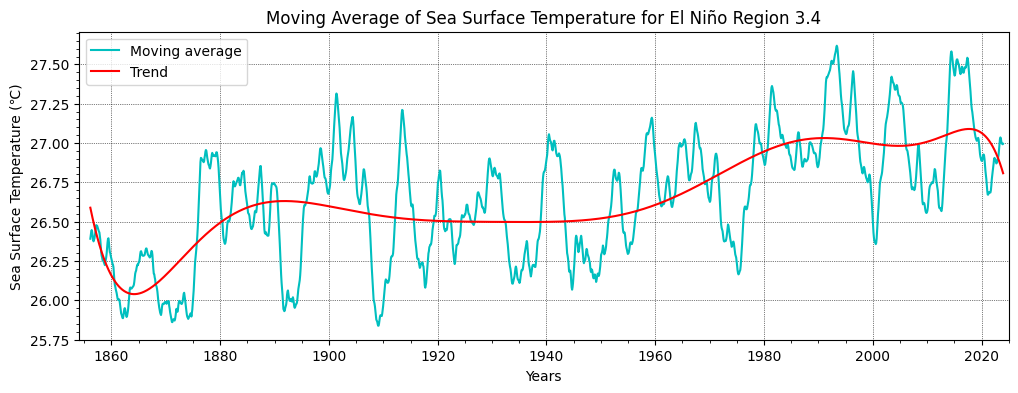

In [47]:
#GRAPH 2: same moving average as above without raw data to increase read-ability (plotted on same x scale but y scale exaggerated)

plt.figure(figsize=(12, 4)) #figure used to 'stretch out' x-axis and make data less cramped
plt.plot(p_year,p_sst,'c',label='Moving average') #plot the moving average
plt.plot(p_year,p_trend,'r',label='Trend', color='red') #plot the trend
plt.xlim([1854,2025]) #limit the x-axis
plt.title('Moving Average of Sea Surface Temperature for El Niño Region 3.4')
plt.xlabel('Years') #label the x-axis
plt.ylabel('Sea Surface Temperature (℃)') #label the y-axis
plt.legend() #add a legend
plt.minorticks_on() #add minorticks
plt.grid(which='major', linestyle=':', linewidth='0.5', color='black')

 The moving average was successful in eliminating the noise. As 'w' increases, more noise is removed; however, it was challenging to determine the correct weight for 'w'. w=50 was selected in an attempt to find a middle ground between not removing too much noise so that the results become "meaningless" and removing enough noise that the results appear "meaningful". The selection of w=50 was highly subjective and based on visual results.

In [39]:
#baseline for sst anomoly calculated from 30 year rolling climatology baseline. BoM currently uses 1991-2020 (I know that's only 29 years but that's what the BoM website says)

sst_1991_2020 = df_sst[(year >= 1991) & (year <= 2020)] #sst data from 1991-2020
baseline = sst_1991_2020['Nino3.4_SST (℃)'].mean()
print(baseline)

27.094957020057304


(1854.0, 2025.0)

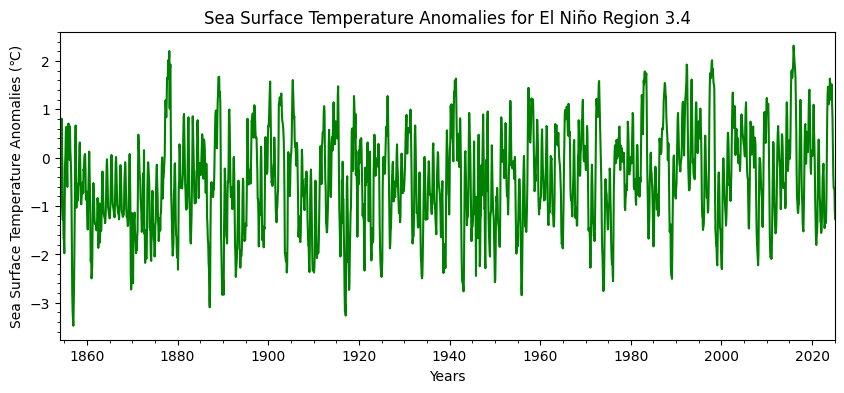

In [48]:
#problem calculating anomaly fixed
anomalies = sst - baseline #calculate anomaly using array broadcasting

plt.figure(figsize=(10, 4)) #figure used to 'stretch out' x-axis and make data less cramped
plt.plot(year,anomalies,'g') #plot the anomalies
plt.title('Sea Surface Temperature Anomalies for El Niño Region 3.4')
plt.xlabel('Years') #label the x-axis
plt.ylabel('Sea Surface Temperature Anomalies (℃)') #label the y-axis
plt.minorticks_on() #add minorticks
plt.xlim([1854,2025]) #limit the x-axis

In [42]:
def freq_spectrum(time,signal):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT (positive freqs only)
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  # Amplitude: scale by 2/n so each peak height equals the true amplitude
  amplitude = (2 / n) * np.abs(fft_vals)
  amplitude[0] /= 2

  return freqs, amplitude

def lowpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqs>cutoff] = 0.0 #cycles above the frequency cutoff are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal

# The following functions are commented out as they were not used in the final analysis.

#def highpass_filter(time,signal,cutoff):

#  n = len(time) #number of data points

#  #interpolate data onto uniformly spaced time
#  x = np.linspace(np.min(time),np.max(time),n)
#  y = np.interp(x,time,signal)

#  sample_rate = 1 / (x[1]-x[0]) #sampling rate
#  fft_vals  = np.fft.rfft(y)    #FFT
#  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

#  fft_vals[freqs<cutoff] = 0.0 #cycles below the frequency cutoff are given an amplitude of 0

#  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

#  return x, filtered_signal

#def bandpass_filter(time,signal,cutoff):

#  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
#  x = np.linspace(np.min(time),np.max(time),n)
#  y = np.interp(x,time,signal)

#  sample_rate = 1 / (x[1]-x[0]) #sampling rate
#  fft_vals  = np.fft.rfft(y)    #FFT
#  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

#  fft_vals[freqs<cutoff[0]] = 0.0 #cycles below cutoff[0] are given an amplitude of 0
#  fft_vals[freqs>cutoff[1]] = 0.0 #cycles above cutoff[1] are given an amplitude of 0

#  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

#  return x, filtered_signal

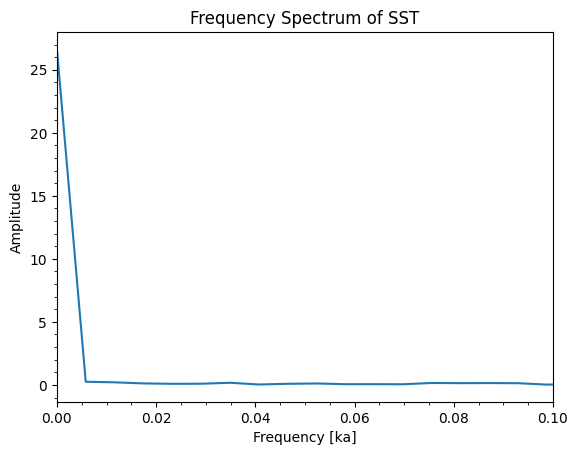

In [ ]:
freqs, amps = freq_spectrum(year,sst) #calculate the frequency spectrum
plt.plot(freqs,amps) #plot the frequency spectrum
plt.xlabel('Frequency [ka]') #label the x-axis
plt.ylabel('Amplitude') #label the y-axis
plt.title('Frequency Spectrum of SST')
plt.xlim([0,0.1]) #limits the x-axis
plt.minorticks_on() #add minorticks

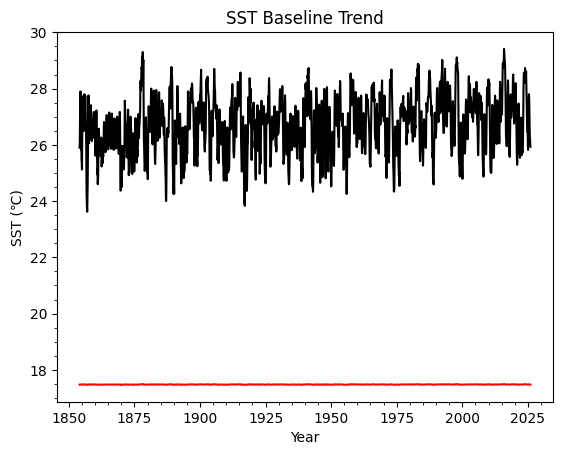

In [ ]:
fitter1 = np.polyfit(year,sst,1) #fit a trendline to the data
plt.plot(year,sst,'k') #plot the original data
plt.plot(year,np.polyval(fitter1,sst),'r') #plot the trendline
plt.xlabel('Year') #label the x-axis
plt.ylabel(r'SST (℃)') #label the y-axis
plt.title('SST Baseline Trend')
#plt.gca().invert_yaxis() #invert the y-axis
#plt.xlim([2000,2005]) #limit the x-axis
plt.minorticks_on() #add minorticks

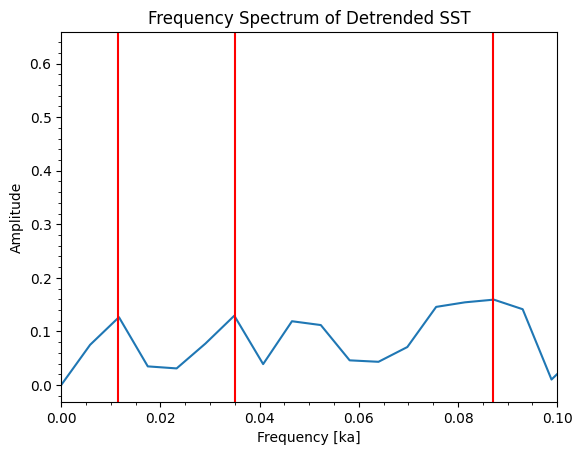

In [ ]:
detrend = sst-np.polyval(fitter1,year) #calculate the detrended data
freqs, amps = freq_spectrum(year,detrend) #frequency spectrum of the detrended data
plt.plot(freqs,amps) #plot the frequency spectrum
plt.xlabel('Frequency [ka]') #label the x-axis
plt.ylabel('Amplitude') #label the y-axis
plt.title('Frequency Spectrum of Detrended SST')
plt.xlim([0,0.1]) #limits the x-axis
plt.minorticks_on() #add minorticks

plt.gca().axvline(x=1/88,color='r') #mark eccentricity frequency
plt.gca().axvline(x=1/28.5,color='r') #mark obliquity frequency
plt.gca().axvline(x=1/11.5,color='r') #mark precession frequency

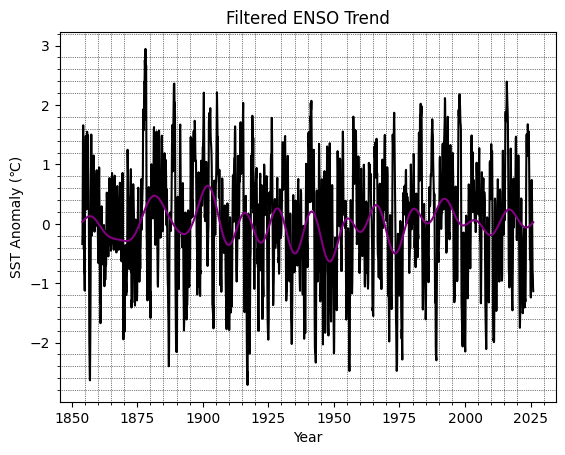

In [ ]:
plt.plot(year,detrend,'k') #plot the detrended data
x, y = lowpass_filter(year,detrend,1/11.5) #obtain the filtered signal
plt.plot(x,y,color='purple') #plot the filtered signal
plt.xlabel('Year') #label the x-axis
plt.ylabel(r'SST Anomaly (℃)') #label the y-axis
plt.title('Filtered ENSO Trend')
#plt.gca().invert_yaxis() #invert the y-axis
#plt.xlim([0,800]) #limit the x-axis
plt.minorticks_on() #add minorticks
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='black')

(1854.0, 2025.0)

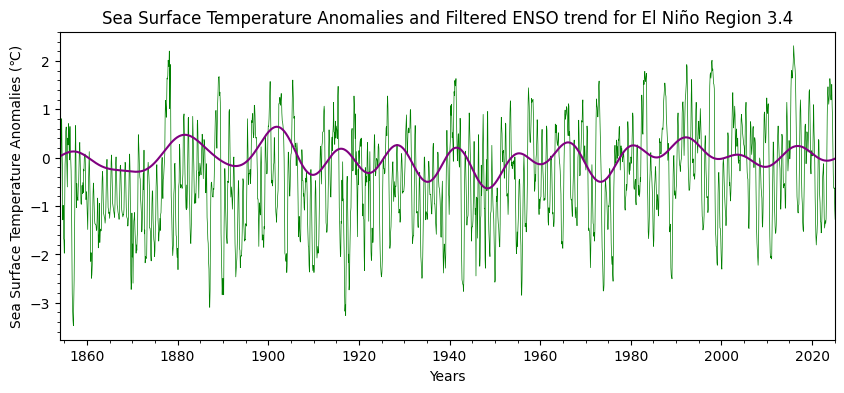

In [49]:
plt.figure(figsize=(10, 4)) #figure used to 'stretch out' x-axis and make data less cramped
plt.plot(year,anomalies,'g',linewidth=0.5) #plot the anomalies
plt.plot(x,y,color='purple') #plot the filtered signal
plt.title('Sea Surface Temperature Anomalies and Filtered ENSO trend for El Niño Region 3.4')
plt.xlabel('Years') #label the x-axis
plt.ylabel('Sea Surface Temperature Anomalies (℃)') #label the y-axis
plt.minorticks_on() #add minorticks
plt.xlim([1854,2025]) #limit the x-axis

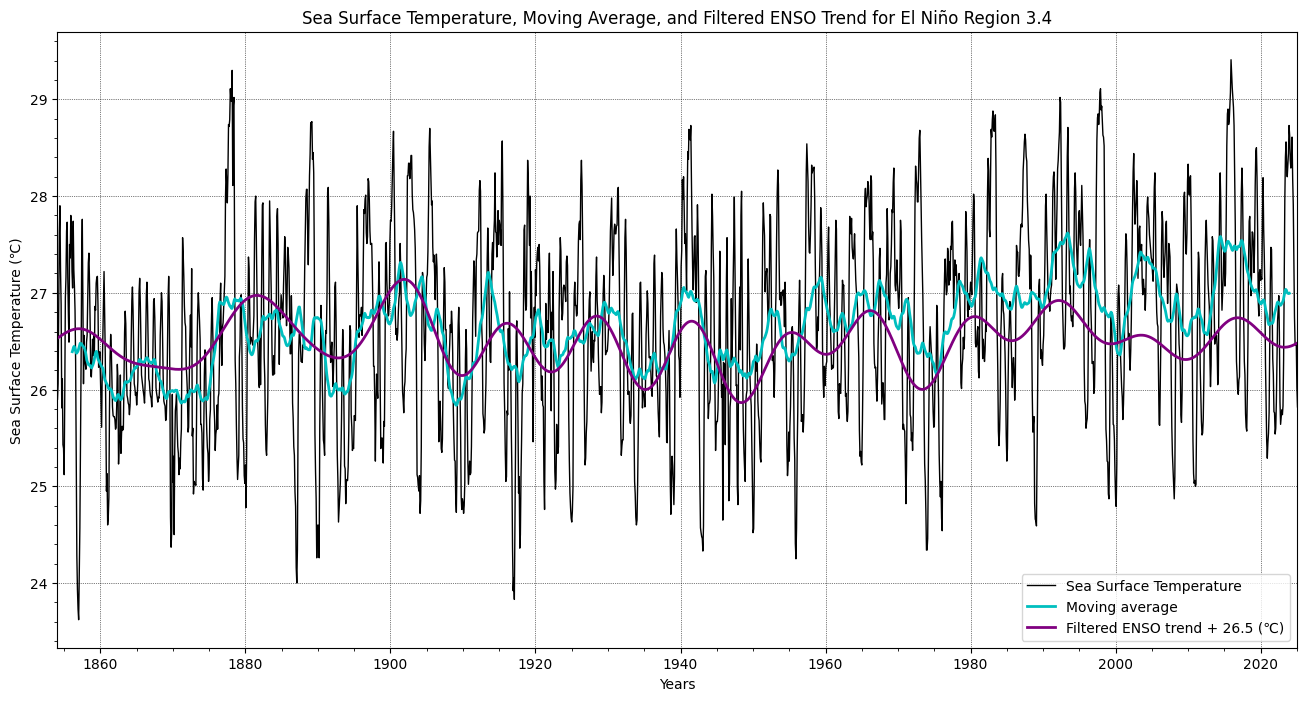

In [50]:
plt.figure(figsize=(16, 8)) #figure used to 'stretch out' x-axis and make data less cramped
#plt.plot(year,detrend,'k',color='darkblue') #plot the detrended data
x, y = lowpass_filter(year,detrend,1/11.5) #obtain the filtered signal
plt.plot(year,sst,'k',linewidth=1,label='Sea Surface Temperature') #plot the raw data
plt.plot(p_year,p_sst,'c',linewidth=2,label='Moving average') #plot the moving average
#plt.plot(year,trend,'r',linewidth=2,label='Trend', color='red') #plot the trend
plt.plot(x,y+26.5,linewidth=2,label='Filtered ENSO trend + 26.5 (℃)',color='purple') #plot the filtered signal
#Note the above plot has been adjusted so it aligns with other plots for visualisation
plt.xlim([1854,2025]) #limit the x-axis
plt.title('Sea Surface Temperature, Moving Average, and Filtered ENSO Trend for El Niño Region 3.4')
plt.xlabel('Years') #label the x-axis
plt.ylabel('Sea Surface Temperature (℃)') #label the y-axis
plt.legend() #add a legend
plt.minorticks_on() #add minorticks
plt.grid(which='major', linestyle=':', linewidth='0.5', color='black')

# Sonya's Analysis

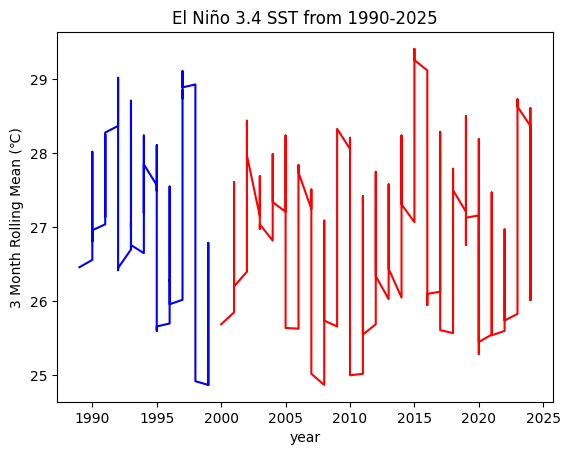

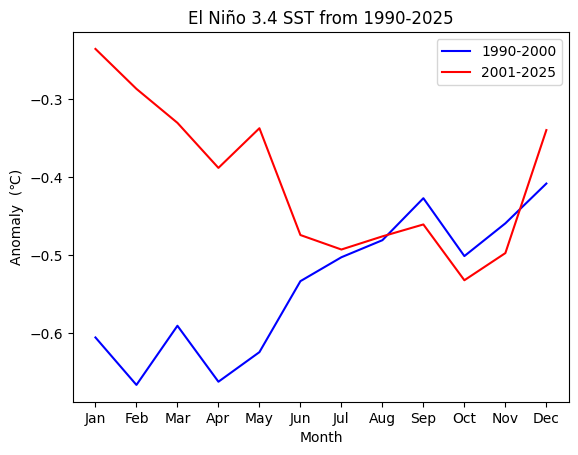

In [51]:
# select data from 1990-2025.
sst_19902000 = df_sst[(year >= 1990) & (year <= 2000)]
sst_20012025 = df_sst[(year >= 2001) & (year <= 2025)]

# calculate climatology
sst_clim_19902000 = sst_19902000.groupby(["Month"]).mean()
sst_clim_20012025 = sst_20012025.groupby(["Month"]).mean()
sst_clim_full_grp = df_sst.groupby(["Month"]).mean()


# calculate anomaly
st_anom_19902000 = sst_clim_full_grp - sst_clim_19902000 # Anomaly between 1990 - 2000
st_anom_20012025 = sst_clim_full_grp - sst_clim_20012025 # Anomaly between 2001 - 2025

# compute 3 month rolling mean
rolling_mean_19902000 = sst_19902000.rolling(window=3, on='Nino3.4_SST (℃)').mean()
rolling_mean_20012025 = sst_20012025.rolling(window=3, on='Nino3.4_SST (℃)').mean()


#df_sst = df_sst.dropna() #remove rows with NaN missing values
r3m_year19902000 = sst_19902000['Year'].to_numpy() #convert years into numpy array
r3m_val_19902000 = rolling_mean_19902000['Nino3.4_SST (℃)'].to_numpy() #convert sst into numpy array
r3m_year20012025 = sst_20012025['Year'].to_numpy() #convert years into numpy array
r3m_val_20012025 = rolling_mean_20012025['Nino3.4_SST (℃)'].to_numpy() #convert sst into numpy array

plt.plot(r3m_year19902000,r3m_val_19902000,'b') #Plot year and sst data
plt.plot(r3m_year20012025,r3m_val_20012025,'r') #Plot year and sst data
plt.xlabel('year')
plt.ylabel('3 Month Rolling Mean (℃)')
plt.title('El Niño 3.4 SST from 1990-2025')
plt.show()



# compare the two ONI time series and visualize the difference as a time series plot
#oni_month19902000 = sst_19902000['Month'].to_numpy() #convert months into numpy array
#oni_month20012025 = sst_19902000["Month"].to_numpy() #convert months into numpy array
on_val_19002000 = st_anom_19902000['Nino3.4_SST (℃)'].to_numpy() #convert SST into numpy array
on_val_20012025 = st_anom_20012025['Nino3.4_SST (℃)'].to_numpy() #convert SST into numpy array
plt.plot(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],on_val_19002000,'b') #Plot month and SST data
plt.plot(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],on_val_20012025,'r') #Plot month and SST data
plt.xlabel('Month')
plt.ylabel('Anomaly  (℃)')
plt.title('El Niño 3.4 SST from 1990-2025')
plt.legend(['1990-2000','2001-2025'],loc='upper right')
plt.show()

# Reflections

**Mia - Data Steward**: I expected to find the data steward role challenging and I was correct! I found it difficult at first to define the scope of the project and find appropriate themes or concepts we could use for time-series analysis that our group would find interesting. I also ran into difficulties finding accessible datasets, and when I found them they were often poorly formatted and without unit labels. I used ChatGPT to reformat the best available dataset I could find, which saved me a lot of time. In the end, I'm really happy with the result of this role, and I learned a lot about managing data FAIR-ly and the challenges of finding quality accessible data.

**Sonya - Analysis**: The biggest challenge was fully understanding the concept of anomalies and then translating that into Python code. Online examples were often difficult to interpret. Specifically, the data in the examples were in year-month-day format, and our data were presented in separate year and month columns. For better presentation in the plots, the numerically denoted months (e.g. 1, 2, 3 ...) were changed to strings (e.g. Jan, Feb, Mar ...). This was also done to ensure the code generated the intended outcomes.

**Sienna - Visualization:** After a few group members received some feedback on our project throughout the week, it became a group effort to do much of the analysis. I originally hadn't allotted much time to getting the visualization portion of the project done this week so time management definitely affected the quality and depth of the work I completed. I also greatly underestimated the amount of analysis coding needing to be completed, initially thinking I was just reworking the moving average before then realizing that further analysis on identifying the ENSO cycles was needed. After spending a few hours trying to problem-solve how to do this, I realized I was going to run out of time, and other team members were able to step in and help finish. While the coding I completed was relatively straightforward and quite similar to what we completed in class, the hardest part of this week's project was wrapping my mind around the problem conceptually. This really highlighted for me how beneficial the class sessions are. Unfortunately, having to do parts of the analysis meant I fell behind and completed only parts of my visualization role, with other team members stepping in to help finish.


**Seth - Narrative**: Creating an easy-to-understand narrative required a little bit more communication with my team this week than I expected. Speaking with all of them to understand their reasoning and logic allowed me to see much more of the story unfold than could be inferred by the code and comments. Although other factors came into play which brought difficulties, we got through them and presented a decent story/narrative.